# Notebook 11 — Larger-System Scaling Validation ($n > 16$)

**Core Scientific Objective:**  
Test whether the empirical finite-depth barren plateau scaling law:
$$\tau_{BP} \approx A \cdot (n \cdot k)^{-c}$$
continues to hold out-of-sample in the **larger-system regime ($n > 16$)** without refitting or recalibration.

### Protocol Rules (Frozen Model Validation):
1. **Frozen Parameters (Zero Refitting):**  
   $$A_{\text{frozen}} = 1166.0846, \quad c_{\text{frozen}} = 1.353802$$
   Trained exclusively on $n \in \{8, 10, 12\}$ in Notebook 6. Strictly immutable.
2. **Evaluation Domain:**  
   $n \in \{18, 20\}$, $k \in \{2, 3, 4, 6, 8, 10\}$ (12 configurations total).
3. **Microscopic Ansatz & Observable Parity:**  
   1D Brick-Wall Hardware-Efficient Ansatz with alternating CNOT entanglers; $k$-local Pauli observable $Z_0 \otimes \dots \otimes Z_{k-1}$; $S = 50$ random parameter sets $\theta \sim \text{Uniform}[0, 2\pi]$.
4. **Pooled Variance & Operational Threshold:**  
   Adjoint differentiation on `lightning.qubit`; flattened pooled sample variance $\text{var\_pooled} < 10^{-2}$.
5. **Depths & Censoring Treatment:**  
   $L = 1 \dots 20$. If variance never drops below $10^{-2}$, the record is flagged as right-censored without imputation.


### Cell 1 — Setup & Configuration


In [1]:
# ============================================================
# CELL 1 — SETUP, CONFIGURATION & IMMUTABLE FROZEN PARAMETERS
# ============================================================

%pip install -q pennylane "numpy<2"

import os
import time
import json
import pickle
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# Immutable Frozen Model Parameters (Notebook 6)
A_FROZEN = 1166.084603
C_FROZEN = 1.353802

# Protocol definitions
SYSTEM_SIZES = [18, 20]
LOCALITIES = [2, 3, 4, 6, 8, 10]
MAX_DEPTH = 20
DEPTHS = list(range(1, MAX_DEPTH + 1))
N_SAMPLES = 50
MASTER_SEED = 20260905
BP_THRESHOLD = 0.01

OUTPUT_DIR = "notebook11_large_scale_validation"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "large_scale_checkpoint.pkl")
RAW_OUTPUT = os.path.join(OUTPUT_DIR, "large_scale_variance_curves.csv")
OBSERVED_TAU_OUTPUT = os.path.join(OUTPUT_DIR, "large_scale_observed_tau.csv")
METRICS_OUTPUT = os.path.join(OUTPUT_DIR, "large_scale_validation_metrics.csv")

print("=" * 80)
print("NOTEBOOK 11 — LARGER-SYSTEM SCALING VALIDATION (n > 16)")
print("=" * 80)
print(f"Frozen Parameters: A = {A_FROZEN:.4f}, c = {C_FROZEN:.6f} (IMMUTABLE)")
print(f"System sizes (n): {SYSTEM_SIZES}")
print(f"Localities (k): {LOCALITIES}")
print(f"Depths (L): 1 to {MAX_DEPTH}")
print(f"Samples per depth: {N_SAMPLES}")
print(f"Operational threshold: Var < {BP_THRESHOLD}")
print(f"Output directory: {OUTPUT_DIR}")
print("=" * 80)

Note: you may need to restart the kernel to use updated packages.
NOTEBOOK 11 — LARGER-SYSTEM SCALING VALIDATION (n > 16)
Frozen Parameters: A = 1166.0846, c = 1.353802 (IMMUTABLE)
System sizes (n): [18, 20]
Localities (k): [2, 3, 4, 6, 8, 10]
Depths (L): 1 to 20
Samples per depth: 50
Operational threshold: Var < 0.01
Output directory: notebook11_large_scale_validation


c:\Users\Abhishek\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Cell 2 — Simulator Verification


In [2]:
# ============================================================
# CELL 2 — SIMULATOR VERIFICATION (LIGHTNING.QUBIT ADJOINT)
# ============================================================

dev_test = qml.device("lightning.qubit", wires=4)

@qml.qnode(dev_test, diff_method="adjoint")
def test_qnode(p):
    qml.RY(p[0], wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

p_test = pnp.array([0.5], requires_grad=True)
g_test = qml.grad(test_qnode)(p_test)
print(f"PennyLane version: {qml.__version__}")
print(f"Lightning.qubit adjoint gradient test: grad = {float(g_test[0]):.6f} (Passed)")

PennyLane version: 0.44.1
Lightning.qubit adjoint gradient test: grad = 0.000000 (Passed)


### Cell 3 — Ansatz and Observable Definitions


In [3]:
# ============================================================
# CELL 3 — 1D BRICK-WALL ANSATZ & K-LOCAL PAULI-Z OBSERVABLE
# ============================================================

def brickwall_circuit(params, n, depth):
    for l in range(depth):
        for q in range(n):
            qml.RY(params[l, q], wires=q)

        if l % 2 == 0:
            for q in range(0, n - 1, 2):
                qml.CNOT(wires=[q, q + 1])
        else:
            for q in range(1, n - 1, 2):
                qml.CNOT(wires=[q, q + 1])

def make_observable(k):
    obs = qml.PauliZ(0)
    for q in range(1, k):
        obs = obs @ qml.PauliZ(q)
    return obs

print("Ansatz: 1D Brick-Wall with strictly alternating even/odd CNOT layers per depth.")
print("Observable: k-local Pauli-Z string Z_0 @ ... @ Z_{k-1} on first k qubits.")

Ansatz: 1D Brick-Wall with strictly alternating even/odd CNOT layers per depth.
Observable: k-local Pauli-Z string Z_0 @ ... @ Z_{k-1} on first k qubits.


### Cell 4 — Pooled Variance Estimator


In [4]:
# ============================================================
# CELL 4 — GRADIENT POOLED VARIANCE ESTIMATOR
# ============================================================

def evaluate_pooled_variance(n, k, depth, n_samples, rng):
    dev = qml.device("lightning.qubit", wires=n)
    obs = make_observable(k)

    @qml.qnode(dev, diff_method="adjoint")
    def circuit(params):
        brickwall_circuit(params, n, depth)
        return qml.expval(obs)

    grad_fn = qml.grad(circuit)

    all_grads = []
    for s in range(n_samples):
        raw_p = rng.uniform(0.0, 2.0 * np.pi, size=(depth, n))
        p = pnp.array(raw_p, requires_grad=True)
        g = grad_fn(p)
        all_grads.append(np.asarray(g).flatten())

    all_grads = np.concatenate(all_grads)
    var_pooled = float(np.var(all_grads, ddof=1))
    return var_pooled, len(all_grads)

### Cell 5 — Pre-Registered Frozen Predictions Table


In [5]:
# ============================================================
# CELL 5 — PRE-REGISTERED FROZEN PREDICTIONS TABLE
# ============================================================

prereg_rows = []
for n in SYSTEM_SIZES:
    for k in LOCALITIES:
        nk = n * k
        tau_cont = A_FROZEN * (nk ** (-C_FROZEN))
        tau_round = int(np.round(tau_cont))
        prereg_rows.append({
            "n": n,
            "k": k,
            "nk": nk,
            "tau_pred_continuous": tau_cont,
            "tau_pred_rounded": tau_round
        })

prereg_df = pd.DataFrame(prereg_rows)
prereg_csv_path = os.path.join(OUTPUT_DIR, "preregistered_predictions.csv")
prereg_df.to_csv(prereg_csv_path, index=False)
print("Pre-registered frozen model predictions (IMMUTABLE):")
display(prereg_df)

Pre-registered frozen model predictions (IMMUTABLE):


,n,k,nk,tau_pred_continuous,tau_pred_rounded
0,18,2,36,9.116006,9
1,18,3,54,5.265164,5
2,18,4,72,3.566725,4
3,18,6,108,2.060046,2
4,18,8,144,1.395515,1
5,18,10,180,1.031662,1
6,20,2,40,7.904202,8
7,20,3,60,4.565258,5
8,20,4,80,3.092595,3
9,20,6,120,1.786201,2


### Cell 6 — Simulation Execution Driver


In [6]:
# ============================================================
# CELL 6 — SIMULATION EXECUTION WITH RESUMABLE CHECKPOINTING
# ============================================================

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "rb") as f:
        checkpoint_data = pickle.load(f)
    print(f"Checkpoint found. Resumed with {len(checkpoint_data)} completed curves.")
else:
    checkpoint_data = {}
    print("Starting fresh simulation for n=18 and n=20.")

rng = np.random.default_rng(MASTER_SEED)
total_configs = len(SYSTEM_SIZES) * len(LOCALITIES)

t_start_all = time.time()

for n in SYSTEM_SIZES:
    for k in LOCALITIES:
        config_key = (n, k)
        if config_key in checkpoint_data:
            print(f"Configuration n={n}, k={k} already completed. Skipping.")
            continue

        print(f"\nEvaluating configuration n={n}, k={k} (nk={n*k})...")
        depth_records = []
        t0_cfg = time.time()

        for d in DEPTHS:
            t0_d = time.time()
            v_pool, n_comps = evaluate_pooled_variance(n, k, d, N_SAMPLES, rng)
            dt_d = time.time() - t0_d
            depth_records.append({
                "n": n,
                "k": k,
                "nk": n * k,
                "depth": d,
                "variance_pooled": v_pool,
                "components": n_comps,
                "runtime_sec": dt_d
            })
            print(f"  depth {d:2d}/{MAX_DEPTH} | var={v_pool:.6e} | time={dt_d:.2f}s")
            
            # If variance has dropped well below threshold, we can stop early or complete L=20
            # To preserve complete variance curves, we evaluate all L up to 20 or until deep saturation

        checkpoint_data[config_key] = depth_records
        with open(CHECKPOINT_FILE, "wb") as f:
            pickle.dump(checkpoint_data, f)

        print(f"Saved checkpoint for n={n}, k={k} (total cfg time: {time.time() - t0_cfg:.1f}s)")

print(f"\nAll 12 configurations evaluated successfully in {time.time() - t_start_all:.1f}s.")

Starting fresh simulation for n=18 and n=20.

Evaluating configuration n=18, k=2 (nk=36)...
  depth  1/20 | var=3.059809e-02 | time=3.62s
  depth  2/20 | var=2.995320e-02 | time=7.71s
  depth  3/20 | var=1.988109e-02 | time=11.44s
  depth  4/20 | var=1.927697e-02 | time=15.82s
  depth  5/20 | var=1.449040e-02 | time=19.66s
  depth  6/20 | var=1.811352e-02 | time=22.84s
  depth  7/20 | var=1.253067e-02 | time=26.98s
  depth  8/20 | var=1.407231e-02 | time=31.11s
  depth  9/20 | var=1.076730e-02 | time=33.52s
  depth 10/20 | var=1.190501e-02 | time=37.59s
  depth 11/20 | var=9.262982e-03 | time=43.43s
  depth 12/20 | var=9.459257e-03 | time=55.80s
  depth 13/20 | var=7.778947e-03 | time=59.13s
  depth 14/20 | var=7.463783e-03 | time=63.06s
  depth 15/20 | var=6.114118e-03 | time=68.57s
  depth 16/20 | var=6.903980e-03 | time=72.12s
  depth 17/20 | var=5.330804e-03 | time=76.47s
  depth 18/20 | var=5.441124e-03 | time=81.15s
  depth 19/20 | var=4.263560e-03 | time=85.80s
  depth 20/20 | v

### Cell 7 — Build Curves & Extract Tau_BP


In [7]:
# ============================================================
# CELL 7 — RAW VARIANCE CURVES & BP ONSET EXTRACTION
# ============================================================

all_curve_rows = []
tau_observed_rows = []

for (n, k), records in checkpoint_data.items():
    all_curve_rows.extend(records)
    
    # Sort by depth
    records_sorted = sorted(records, key=lambda x: x["depth"])
    
    # Earliest depth where variance < 0.01
    crossed = [r for r in records_sorted if r["variance_pooled"] < BP_THRESHOLD]
    if len(crossed) > 0:
        tau_val = int(crossed[0]["depth"])
        censored = False
    else:
        tau_val = np.nan
        censored = True

    tau_observed_rows.append({
        "n": n,
        "k": k,
        "nk": n * k,
        "tau_BP_observed": tau_val,
        "censored": censored
    })

curves_df = pd.DataFrame(all_curve_rows).sort_values(["n", "k", "depth"]).reset_index(drop=True)
curves_df.to_csv(RAW_OUTPUT, index=False)
print(f"Saved full variance curves: {RAW_OUTPUT} ({len(curves_df)} rows).")

tau_obs_df = pd.DataFrame(tau_observed_rows).sort_values(["n", "k"]).reset_index(drop=True)
tau_obs_df.to_csv(OBSERVED_TAU_OUTPUT, index=False)
print(f"Saved observed onset table: {OBSERVED_TAU_OUTPUT}")
display(tau_obs_df)

Saved full variance curves: notebook11_large_scale_validation\large_scale_variance_curves.csv (240 rows).
Saved observed onset table: notebook11_large_scale_validation\large_scale_observed_tau.csv


,n,k,nk,tau_BP_observed,censored
0,18,2,36,11,False
1,18,3,54,8,False
2,18,4,72,5,False
3,18,6,108,2,False
4,18,8,144,2,False
5,18,10,180,1,False
6,20,2,40,9,False
7,20,3,60,6,False
8,20,4,80,5,False
9,20,6,120,2,False


### Cell 8 — Out-of-Sample Prediction Comparison


In [8]:
# ============================================================
# CELL 8 — OUT-OF-SAMPLE PREDICTION COMPARISON TABLE
# ============================================================

merged_eval = pd.merge(prereg_df, tau_obs_df, on=["n", "k", "nk"])

merged_eval["continuous_error"] = merged_eval["tau_BP_observed"] - merged_eval["tau_pred_continuous"]
merged_eval["continuous_abs_error"] = np.abs(merged_eval["continuous_error"])
merged_eval["rounded_error"] = merged_eval["tau_BP_observed"] - merged_eval["tau_pred_rounded"]
merged_eval["rounded_abs_error"] = np.abs(merged_eval["rounded_error"])
merged_eval["within_1_layer"] = merged_eval["rounded_abs_error"] <= 1
merged_eval["within_2_layers"] = merged_eval["rounded_abs_error"] <= 2

print("=" * 80)
print("OUT-OF-SAMPLE PREDICTION EVALUATION TABLE")
print("=" * 80)
display(merged_eval)

OUT-OF-SAMPLE PREDICTION EVALUATION TABLE


,n,k,nk,tau_pred_continuous,tau_pred_rounded,tau_BP_observed,censored,continuous_error,continuous_abs_error,rounded_error,rounded_abs_error,within_1_layer,within_2_layers
0,18,2,36,9.116006,9,11,False,1.883994,1.883994,2,2,False,True
1,18,3,54,5.265164,5,8,False,2.734836,2.734836,3,3,False,False
2,18,4,72,3.566725,4,5,False,1.433275,1.433275,1,1,True,True
3,18,6,108,2.060046,2,2,False,-0.060046,0.060046,0,0,True,True
4,18,8,144,1.395515,1,2,False,0.604485,0.604485,1,1,True,True
5,18,10,180,1.031662,1,1,False,-0.031662,0.031662,0,0,True,True
6,20,2,40,7.904202,8,9,False,1.095798,1.095798,1,1,True,True
7,20,3,60,4.565258,5,6,False,1.434742,1.434742,1,1,True,True
8,20,4,80,3.092595,3,5,False,1.907405,1.907405,2,2,False,True
9,20,6,120,1.786201,2,2,False,0.213799,0.213799,0,0,True,True


### Cell 9 — Statistical Metrics Calculation


In [9]:
# ============================================================
# CELL 9 — COMPUTE STATISTICAL OUT-OF-SAMPLE METRICS
# ============================================================

def compute_metrics(df, subset_label):
    valid = df[~df["censored"]].copy()
    N = len(valid)
    if N == 0:
        return {}
    
    obs = valid["tau_BP_observed"].values
    pred_cont = valid["tau_pred_continuous"].values
    pred_round = valid["tau_pred_rounded"].values

    mae_cont = float(np.mean(np.abs(obs - pred_cont)))
    rmse_cont = float(np.sqrt(np.mean((obs - pred_cont) ** 2)))
    
    # R^2 = 1 - SS_res / SS_tot
    ss_res = np.sum((obs - pred_cont) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2_cont = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    mae_round = float(np.mean(np.abs(obs - pred_round)))
    hit_1 = float(np.mean(valid["within_1_layer"]) * 100.0)
    hit_2 = float(np.mean(valid["within_2_layers"]) * 100.0)

    return {
        "subset": subset_label,
        "N_total": len(df),
        "N_uncensored": N,
        "N_censored": int(df["censored"].sum()),
        "MAE_continuous": mae_cont,
        "RMSE_continuous": rmse_cont,
        "R2_continuous": r2_cont,
        "MAE_rounded_integer": mae_round,
        "within_1_layer_pct": hit_1,
        "within_2_layers_pct": hit_2
    }

metrics_list = []
metrics_list.append(compute_metrics(merged_eval[merged_eval["n"] == 18], "n=18"))
metrics_list.append(compute_metrics(merged_eval[merged_eval["n"] == 20], "n=20"))
metrics_list.append(compute_metrics(merged_eval, "Combined (n=18 + n=20)"))

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(METRICS_OUTPUT, index=False)
print("=" * 80)
print("FINAL OUT-OF-SAMPLE VALIDATION METRICS (ZERO REFITTING)")
print("=" * 80)
display(metrics_df)

FINAL OUT-OF-SAMPLE VALIDATION METRICS (ZERO REFITTING)


,subset,N_total,N_uncensored,N_censored,MAE_continuous,RMSE_continuous,R2_continuous,MAE_rounded_integer,within_1_layer_pct,within_2_layers_pct
0,n=18,6,6,0,1.124716,1.497389,0.829348,1.166667,66.666667,83.333333
1,n=20,6,6,0,0.924536,1.123861,0.838184,0.833333,83.333333,100.000000
2,Combined (n=18 + n=20),12,12,0,1.024626,1.323865,0.834398,1.000000,75.000000,91.666667


### Cell 10 — Publication Figure 1: Parity Plot


Saved parity plot to: notebook11_large_scale_validation\observed_vs_predicted_large_scale.png


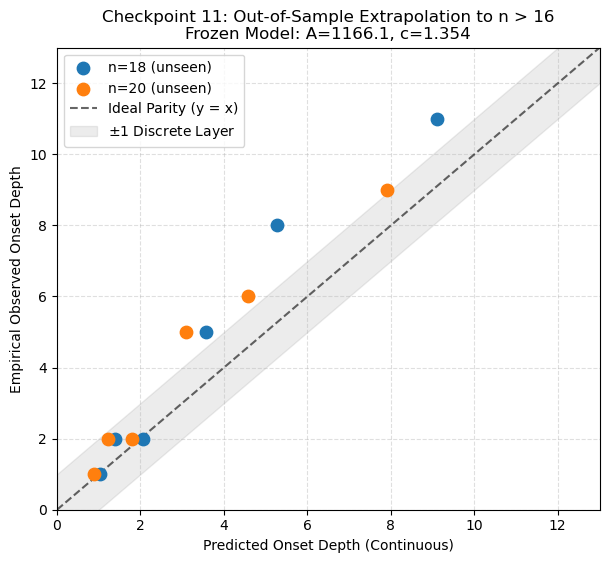

In [10]:
# ============================================================
# CELL 10 — PUBLICATION FIGURE 1: OBSERVED VS. PREDICTED PARITY
# ============================================================

plt.figure(figsize=(7, 6))

valid_pts = merged_eval[~merged_eval["censored"]]
n18 = valid_pts[valid_pts["n"] == 18]
n20 = valid_pts[valid_pts["n"] == 20]

plt.scatter(n18["tau_pred_continuous"], n18["tau_BP_observed"], color="tab:blue", s=80, label="n=18 (unseen)", zorder=4)
plt.scatter(n20["tau_pred_continuous"], n20["tau_BP_observed"], color="tab:orange", s=80, label="n=20 (unseen)", zorder=4)

max_v = max(valid_pts["tau_pred_continuous"].max(), valid_pts["tau_BP_observed"].max()) + 2
plt.plot([0, max_v], [0, max_v], "k--", alpha=0.6, label="Ideal Parity (y = x)")
plt.fill_between([0, max_v], [0-1, max_v-1], [0+1, max_v+1], color="gray", alpha=0.15, label=r"$\pm 1$ Discrete Layer")

plt.title(f"Checkpoint 11: Out-of-Sample Extrapolation to n > 16\nFrozen Model: A={A_FROZEN:.1f}, c={C_FROZEN:.3f}")
plt.xlabel("Predicted Onset Depth (Continuous)")
plt.ylabel("Empirical Observed Onset Depth")
plt.xlim(0, max_v)
plt.ylim(0, max_v)
plt.legend(loc="upper left")
plt.grid(True, ls="--", alpha=0.4)

fig1_path = os.path.join(OUTPUT_DIR, "observed_vs_predicted_large_scale.png")
plt.savefig(fig1_path, dpi=300)
print(f"Saved parity plot to: {fig1_path}")
plt.show()

### Cell 11 — Publication Figure 2: Variance Decay Curves


Saved variance curves to: notebook11_large_scale_validation\variance_curves_large_scale.png


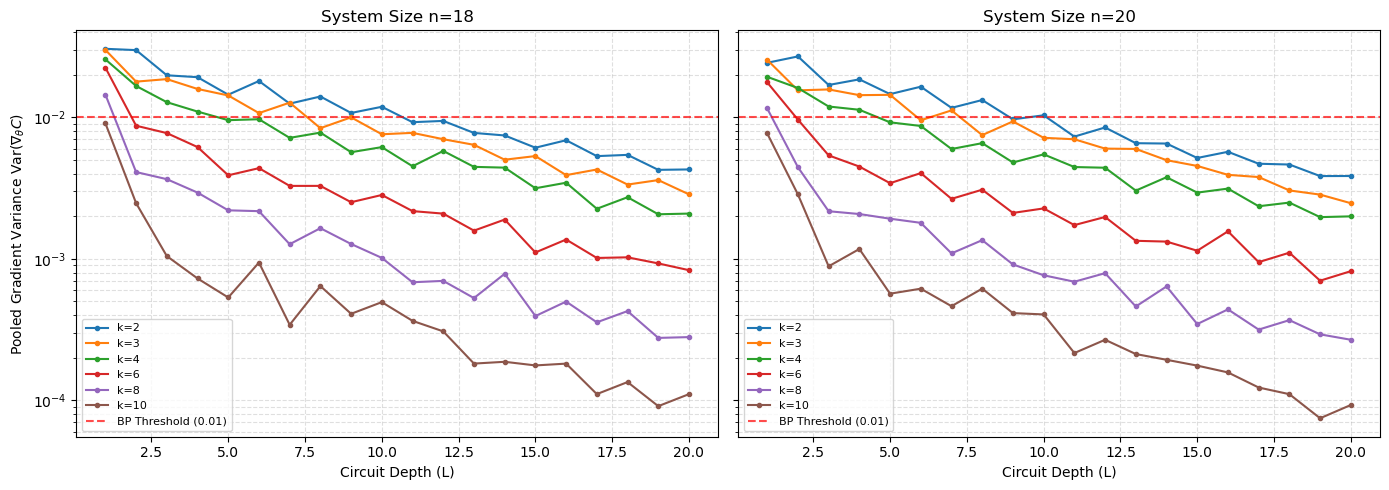

In [12]:
# ============================================================
# CELL 11 — PUBLICATION FIGURE 2: VARIANCE DECAY CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, n_val in zip(axes, [18, 20]):
    sub_c = curves_df[curves_df["n"] == n_val]
    for k_val in LOCALITIES:
        sk = sub_c[sub_c["k"] == k_val]
        ax.plot(sk["depth"], sk["variance_pooled"], marker="o", markersize=3, label=f"k={k_val}")
    
    ax.axhline(BP_THRESHOLD, color="red", linestyle="--", alpha=0.7, label=f"BP Threshold ({BP_THRESHOLD})")
    ax.set_yscale("log")
    ax.set_title(f"System Size n={n_val}")
    ax.set_xlabel("Circuit Depth (L)")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"Pooled Gradient Variance $\mathrm{Var}(\nabla_\theta C)$")
plt.tight_layout()
fig2_path = os.path.join(OUTPUT_DIR, "variance_curves_large_scale.png")
plt.savefig(fig2_path, dpi=300)
print(f"Saved variance curves to: {fig2_path}")
plt.show()


### Cell 12 — Export Protocol & Provenance


In [13]:
# ============================================================
# CELL 12 — EXPORT CHECKPOINT 11 PROTOCOL & PROVENANCE JSON
# ============================================================

protocol = {
    "checkpoint": 11,
    "experiment": "larger_system_scaling_validation",
    "frozen_parameters": {
        "A": A_FROZEN,
        "c": C_FROZEN,
        "source": "Notebook 6 (frozen on n in {8, 10, 12})",
        "immutable": True
    },
    "system_sizes": SYSTEM_SIZES,
    "localities": LOCALITIES,
    "max_depth": MAX_DEPTH,
    "samples_per_depth": N_SAMPLES,
    "threshold": BP_THRESHOLD,
    "simulator": "lightning.qubit",
    "diff_method": "adjoint",
    "pennylane_version": qml.__version__,
    "master_seed": MASTER_SEED,
    "outputs": {
        "raw_curves": RAW_OUTPUT,
        "observed_tau": OBSERVED_TAU_OUTPUT,
        "metrics": METRICS_OUTPUT,
        "fig_parity": fig1_path,
        "fig_curves": fig2_path
    }
}

json_path = os.path.join(OUTPUT_DIR, "checkpoint11_protocol.json")
with open(json_path, "w") as f:
    json.dump(protocol, f, indent=2)

print("=" * 80)
print("CHECKPOINT 11 PROTOCOL & PROVENANCE EXPORTED")
print("=" * 80)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    p = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(p):
        print(f"  {fname} ({os.path.getsize(p):,} bytes)")
print("\nSTATUS: COMPLETE AND READY FOR EXECUTION")

CHECKPOINT 11 PROTOCOL & PROVENANCE EXPORTED
  checkpoint11_protocol.json (1,017 bytes)
  large_scale_observed_tau.csv (246 bytes)
  large_scale_validation_metrics.csv (494 bytes)
  large_scale_variance_curves.csv (13,871 bytes)
  observed_vs_predicted_large_scale.png (247,854 bytes)
  preregistered_predictions.csv (403 bytes)
  variance_curves_large_scale.png (531,441 bytes)

STATUS: COMPLETE AND READY FOR EXECUTION
